# Exact role-constrained Bayesian network — metallurgie

This notebook reports the exact A0 → A1 → B → C Bayesian network and the
empirical recurrent-scenario analysis. Scenario selection remains independent
of the Bayesian network. Edge directions follow the predefined role ordering
and are not causal directions inferred from the data.


In [1]:
from pathlib import Path
import sys
import warnings
import pandas as pd
from IPython.display import Image, display

warnings.filterwarnings(
    "ignore",
    message=r"(?s).*support for the `google[.]generativeai` package has ended.*",
    category=FutureWarning,
)
SCENARIO_DIR = next(
    candidate
    for base in (Path.cwd(), *Path.cwd().parents)
    for candidate in (base / "text" / "recurrent_scenarios", base)
    if (candidate / "scenario_pipeline.py").is_file()
)
if str(SCENARIO_DIR) not in sys.path:
    sys.path.insert(0, str(SCENARIO_DIR))
from scenario_analysis import _output_paths, run_global_bn_scenario_mining
from scenario_pipeline import load_bn_analysis_config, load_selected_configurations


In [2]:
DATASET_ID = 'metallurgie'
RUN_DIR = SCENARIO_DIR / "runs" / "theme_discovery_audit" / DATASET_ID
CONFIG_PATH = SCENARIO_DIR / "config.yaml"
RUN_ANALYSIS = False  # Use the Slurm job for the 500-replicate bootstrap.
config = load_bn_analysis_config(CONFIG_PATH, DATASET_ID, RUN_DIR)
selections = load_selected_configurations(RUN_DIR)
paths = _output_paths(RUN_DIR)
print("Dataset:", DATASET_ID)
print("Output:", paths["root"])
print("Structure optimization: exact within the role-constrained graph class")
print("Bootstrap resamples:", config["bayesian_networks"]["bn_structure_bootstrap"]["n_resamples"])
print("Selected partitions:", selections)


Dataset: metallurgie
Output: C:\Users\aho\Documents\analysis factor project\SAFER\text\recurrent_scenarios\runs\theme_discovery_audit\metallurgie\bn_results_exact
Structure optimization: exact within the role-constrained graph class
Bootstrap resamples: 500
Selected partitions: {'A0': 'A0_cfg_011', 'A1': 'A1_cfg_033', 'B': 'B_cfg_071', 'C': 'C_cfg_027'}


## 1. Accident-level matrix and exact structure


In [3]:
if RUN_ANALYSIS:
    analysis = run_global_bn_scenario_mining(config, RUN_DIR, selections)
if not (paths["network"] / "global_bn_summary.csv").is_file():
    raise FileNotFoundError("Exact BN outputs are absent. Launch jobs/run_recurrent_scenarios_bn_exact.sh first.")
summary = pd.read_csv(paths["network"] / "global_bn_summary.csv")
local_scores = pd.read_csv(paths["network"] / "bn_local_scores.csv")
selected_parent_sets = pd.read_csv(paths["network"] / "bn_selected_parent_sets.csv")
display(summary)
display(selected_parent_sets)
summary_row = summary.iloc[0]
print("Variables:", int(summary_row["n_variables"]))
print("Local parent sets evaluated:", int(summary_row["n_local_parent_sets_evaluated"]))
print("Selected edges:", int(summary_row["n_edges"]))
print("Parameters:", int(summary_row["n_parameters"]))
print("Log-likelihood:", float(summary_row["log_likelihood"]))
print("BIC:", float(summary_row["BIC"]))


,structure_optimization,n_accidents,n_variables,n_A0,n_A1,n_B,n_C,n_local_parent_sets_evaluated,n_edges,n_A0_to_A1,n_A0_to_B,n_A1_to_B,n_B_to_C,n_parameters,log_likelihood,BIC,final_CPT_estimation,max_observed_parents,completed
0,exact_role_constrained_local_BIC,3212,105,39,16,11,39,32099,57,17,13,3,24,173,-39563.941687,80524.797665,Jeffreys,2,True


,child_factor,child_role,parent_factor_ids,n_parents,log_likelihood,n_parameters,BIC,n_BIC_minimum_ties,tie_break
0,A0__T01,A0,NaN,0,-310.063485,1,628.201619,1,not_required
1,A0__T02,A0,NaN,0,-388.973828,1,786.022305,1,not_required
2,A0__T03,A0,NaN,0,-441.931787,1,891.938224,1,not_required
3,A0__T04,A0,NaN,0,-685.065381,1,1378.205412,1,not_required
4,A0__T05,A0,NaN,0,-515.433602,1,1038.941853,1,not_required
...,...,...,...,...,...,...,...,...,...
100,C__T35,C,B__T07,1,-171.202264,2,358.553826,1,not_required
101,C__T36,C,NaN,0,-294.284363,1,596.643376,1,not_required
102,C__T37,C,B__T06,1,-448.943194,2,914.035685,1,not_required
103,C__T38,C,B__T07,1,-178.209025,2,372.567348,1,not_required


Variables: 105
Local parent sets evaluated: 32099
Selected edges: 57
Parameters: 173
Log-likelihood: -39563.94168739068
BIC: 80524.7976647679


## 2. Assess support of selected conditional-probability tables


In [4]:
display(local_scores.sort_values(["child_factor", "rank"]).head(30))
support_diagnostics = pd.read_csv(paths["network"] / "bn_cpt_support_diagnostics.csv")
diagnostic = support_diagnostics.iloc[0]
print("Selected BN:")
print("CPT rows:", diagnostic["n_cpt_rows"])
print("Empty rows (N = 0):", diagnostic["n_rows_N_eq_0"])
print("Rows with N <= 5:", diagnostic["n_rows_N_le_5"])
print("Rows with N <= 10:", diagnostic.get("n_rows_N_le_10", "available after the next exact-BN run"))
print("Rows with N <= 20:", diagnostic.get("n_rows_N_le_20", "available after the next exact-BN run"))
print("MLE estimates equal to 0:", diagnostic["n_MLE_equal_0"])
print("MLE estimates equal to 1:", diagnostic["n_MLE_equal_1"])
print("Minimum observed cell count:", diagnostic["minimum_observed_cell_count"])
print("Median observed cell count:", diagnostic["median_observed_cell_count"])
print("Final CPT estimator:", diagnostic["final_CPT_estimation"])
display(support_diagnostics)
final_cpts = pd.read_csv(paths["network"] / "bn_final_cpts.csv")
display(final_cpts.head(30))
if diagnostic["final_CPT_estimation"] == "Jeffreys":
    print("Jeffreys regularization was used because the configured support criterion was not met.")
    display(pd.read_csv(paths["network"] / "bn_mle_cpts.csv").head(30))


,child_factor,child_role,parent_factor_ids,n_parents,log_likelihood,n_parameters,BIC,BIC_tied_for_minimum,selected,rank
0,A0__T01,A0,NaN,0,-310.063485,1,628.201619,True,True,1
1,A0__T02,A0,NaN,0,-388.973828,1,786.022305,True,True,1
2,A0__T03,A0,NaN,0,-441.931787,1,891.938224,True,True,1
3,A0__T04,A0,NaN,0,-685.065381,1,1378.205412,True,True,1
4,A0__T05,A0,NaN,0,-515.433602,1,1038.941853,True,True,1
5,A0__T06,A0,NaN,0,-435.014361,1,878.103371,True,True,1
6,A0__T07,A0,NaN,0,-236.742690,1,481.560028,True,True,1
7,A0__T08,A0,NaN,0,-337.062401,1,682.199452,True,True,1
8,A0__T09,A0,NaN,0,-306.143642,1,620.361933,True,True,1
9,A0__T10,A0,NaN,0,-759.712050,1,1527.498748,True,True,1


Selected BN:
CPT rows: 173
Empty rows (N = 0): 1
Rows with N <= 5: 1
Rows with N <= 10: 6
Rows with N <= 20: 7
MLE estimates equal to 0: 7
MLE estimates equal to 1: 0
Minimum observed cell count: 6
Median observed cell count: 3012.0
Final CPT estimator: Jeffreys


,n_cpt_rows,n_rows_N_eq_0,n_rows_N_le_2,n_rows_N_le_5,n_rows_N_le_10,n_rows_N_le_20,n_MLE_equal_0,n_MLE_equal_1,minimum_observed_cell_count,median_observed_cell_count,regularization_min_observed_count,n_rows_at_or_below_regularization_threshold,final_CPT_estimation,regularization_required
0,173,1,1,1,6,7,7,0,6,3012.0,0,1,Jeffreys,True


,child_factor,child_role,parent_factor_ids,parent_values,n_parent_configuration,n_child_1,n_child_0,parent_configuration_observed,MLE_P_child_1,MLE_P_child_0,Jeffreys_P_child_1,Jeffreys_P_child_0,CPT_estimation,P_child_1,P_child_0
0,A0__T01,A0,NaN,NaN,3212,63,3149,True,0.019614,0.980386,0.019763,0.980237,Jeffreys,0.019763,0.980237
1,A0__T02,A0,NaN,NaN,3212,84,3128,True,0.026152,0.973848,0.026299,0.973701,Jeffreys,0.026299,0.973701
2,A0__T03,A0,NaN,NaN,3212,99,3113,True,0.030822,0.969178,0.030968,0.969032,Jeffreys,0.030968,0.969032
3,A0__T04,A0,NaN,NaN,3212,177,3035,True,0.055106,0.944894,0.055244,0.944756,Jeffreys,0.055244,0.944756
4,A0__T05,A0,NaN,NaN,3212,121,3091,True,0.037671,0.962329,0.037815,0.962185,Jeffreys,0.037815,0.962185
5,A0__T06,A0,NaN,NaN,3212,97,3115,True,0.030199,0.969801,0.030345,0.969655,Jeffreys,0.030345,0.969655
6,A0__T07,A0,NaN,NaN,3212,45,3167,True,0.014010,0.985990,0.014161,0.985839,Jeffreys,0.014161,0.985839
7,A0__T08,A0,NaN,NaN,3212,70,3142,True,0.021793,0.978207,0.021942,0.978058,Jeffreys,0.021942,0.978058
8,A0__T09,A0,NaN,NaN,3212,62,3150,True,0.019303,0.980697,0.019452,0.980548,Jeffreys,0.019452,0.980548
9,A0__T10,A0,NaN,NaN,3212,204,3008,True,0.063512,0.936488,0.063648,0.936352,Jeffreys,0.063648,0.936352


Jeffreys regularization was used because the configured support criterion was not met.


,child_factor,child_role,parent_factor_ids,parent_values,n_parent_configuration,n_child_1,n_child_0,parent_configuration_observed,MLE_P_child_1,MLE_P_child_0,Jeffreys_P_child_1,Jeffreys_P_child_0
0,A0__T01,A0,NaN,NaN,3212,63,3149,True,0.019614,0.980386,0.019763,0.980237
1,A0__T02,A0,NaN,NaN,3212,84,3128,True,0.026152,0.973848,0.026299,0.973701
2,A0__T03,A0,NaN,NaN,3212,99,3113,True,0.030822,0.969178,0.030968,0.969032
3,A0__T04,A0,NaN,NaN,3212,177,3035,True,0.055106,0.944894,0.055244,0.944756
4,A0__T05,A0,NaN,NaN,3212,121,3091,True,0.037671,0.962329,0.037815,0.962185
5,A0__T06,A0,NaN,NaN,3212,97,3115,True,0.030199,0.969801,0.030345,0.969655
6,A0__T07,A0,NaN,NaN,3212,45,3167,True,0.014010,0.985990,0.014161,0.985839
7,A0__T08,A0,NaN,NaN,3212,70,3142,True,0.021793,0.978207,0.021942,0.978058
8,A0__T09,A0,NaN,NaN,3212,62,3150,True,0.019303,0.980697,0.019452,0.980548
9,A0__T10,A0,NaN,NaN,3212,204,3008,True,0.063512,0.936488,0.063648,0.936352


## 3. Structural bootstrap and conditional contrasts


57 full-sample edges; 41 with f >= 0.60
Stable edges by transition:


,transition,n_edges
0,B->C,19
1,A0->A1,11
2,A0->B,9
3,A1->B,2


,parent_label,child_label,transition,bootstrap_frequency,conditional_contrast_weighted,conditional_contrast_min,conditional_contrast_max,conditional_contrast_pattern
0,B_000,C_023,B->C,1.000,0.104773,0.104773,0.104773,monotonically_positive
4,B_000,C_022,B->C,1.000,0.114542,0.114542,0.114542,monotonically_positive
5,B_005,C_000,B->C,1.000,0.190390,0.190390,0.190390,monotonically_positive
1,A0_034,B_005,A0->B,1.000,-0.072261,-0.072261,-0.072261,monotonically_negative
3,B_000,C_014,B->C,1.000,0.133827,0.133827,0.133827,monotonically_positive
2,B_006,C_034,B->C,1.000,0.068416,0.068416,0.068416,monotonically_positive
6,A0_029,B_010,A0->B,0.998,0.436221,-0.073090,0.443947,non_monotone
7,A0_015,B_003,A0->B,0.998,0.149545,0.149058,0.196429,monotonically_positive
8,A0_031,B_009,A0->B,0.996,0.116707,0.043767,0.118618,monotonically_positive
9,B_006,C_009,B->C,0.994,-0.032000,-0.032248,-0.026515,monotonically_negative


,parent_factor,child_factor,other_parent_configuration,n_parent_0,n_parent_1,n_context,estimable,CPT_estimation,P_child_1_parent_0,P_child_1_parent_1,conditional_contrast
0,A0__T03,A1__T03,NaN,3113,99,3212,True,Jeffreys,0.013969,0.155000,0.141031
1,A0__T04,B__T07,A0__T10=0,2858,150,3008,True,Jeffreys,0.092515,0.248344,0.155830
2,A0__T04,B__T07,A0__T10=1,177,27,204,True,Jeffreys,0.272472,0.517857,0.245385
3,A0__T05,A1__T01,A0__T11=0,3026,114,3140,True,Jeffreys,0.005451,0.082609,0.077158
4,A0__T05,A1__T01,A0__T11=1,65,7,72,True,Jeffreys,0.098485,0.187500,0.089015
5,A0__T05,A1__T02,A0__T06=0,3009,106,3115,True,Jeffreys,0.021429,0.210280,0.188852
6,A0__T05,A1__T02,A0__T06=1,82,15,97,True,Jeffreys,0.198795,0.281250,0.082455
7,A0__T05,B__T01,A1__T02=0,3011,95,3106,True,Jeffreys,0.041667,0.317708,0.276042
8,A0__T05,B__T01,A1__T02=1,80,26,106,True,Jeffreys,0.376543,0.462963,0.086420
9,A0__T06,A1__T02,A0__T05=0,3009,82,3091,True,Jeffreys,0.021429,0.198795,0.177367


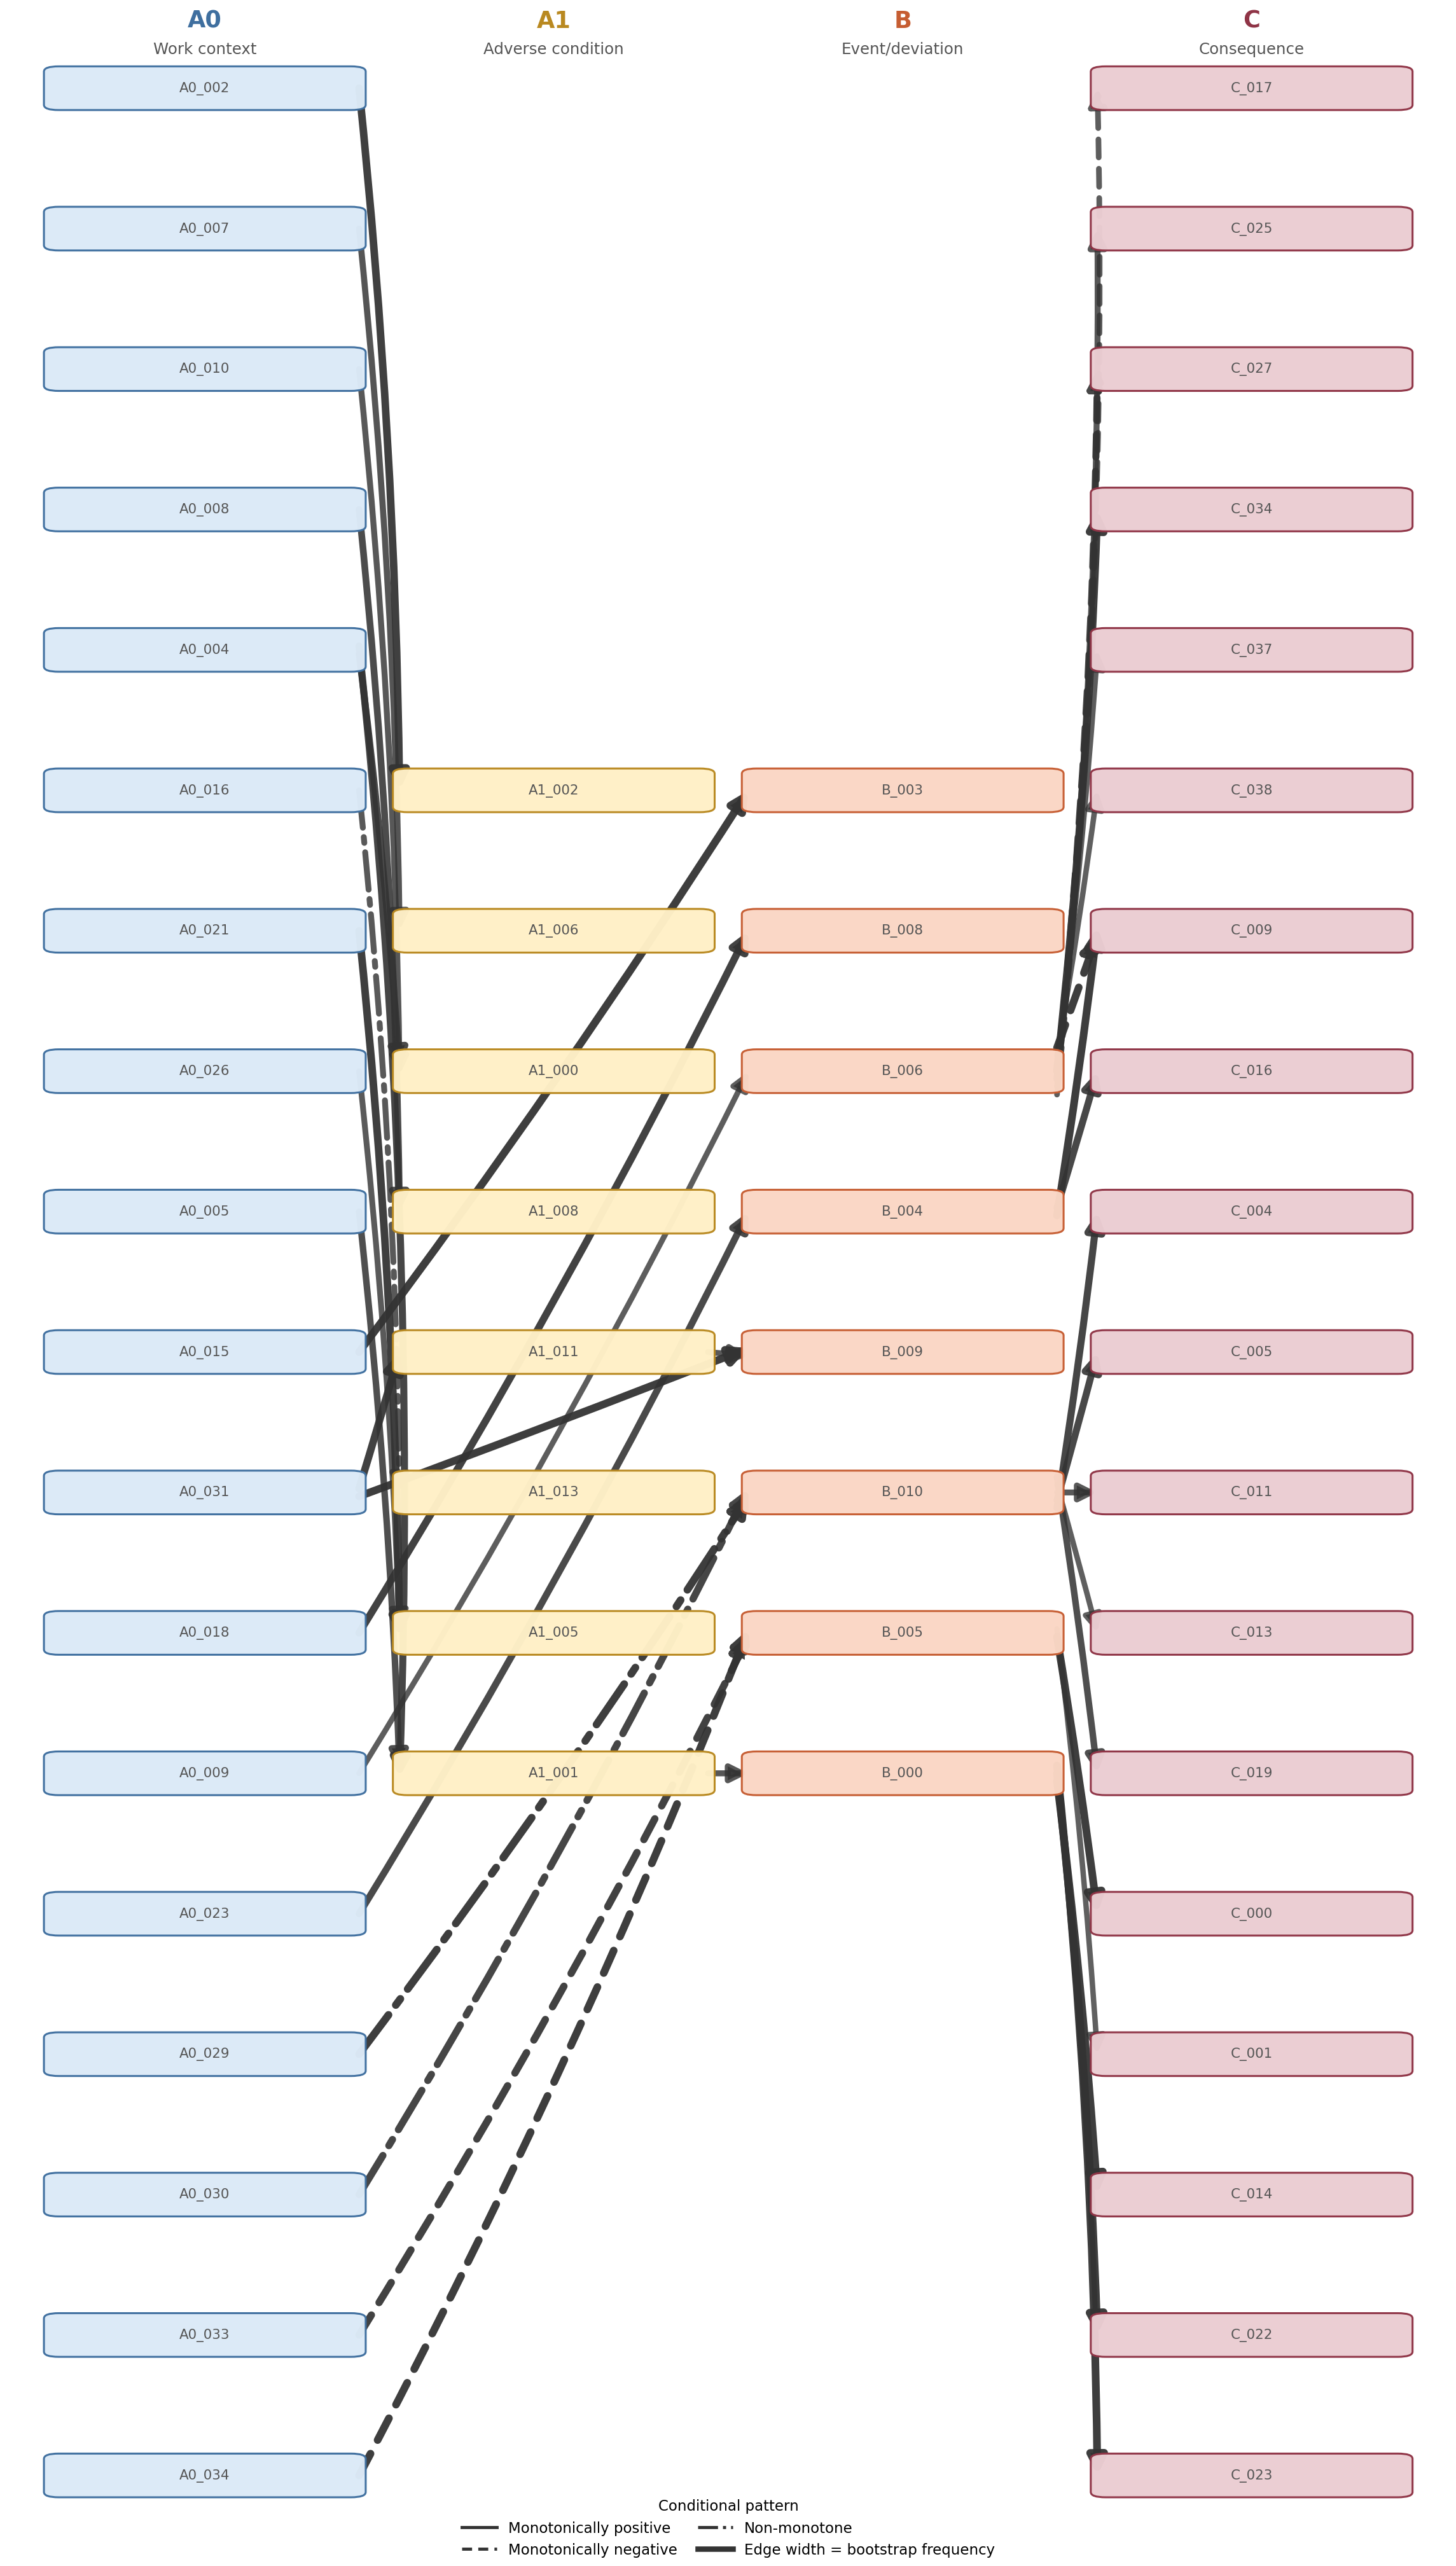

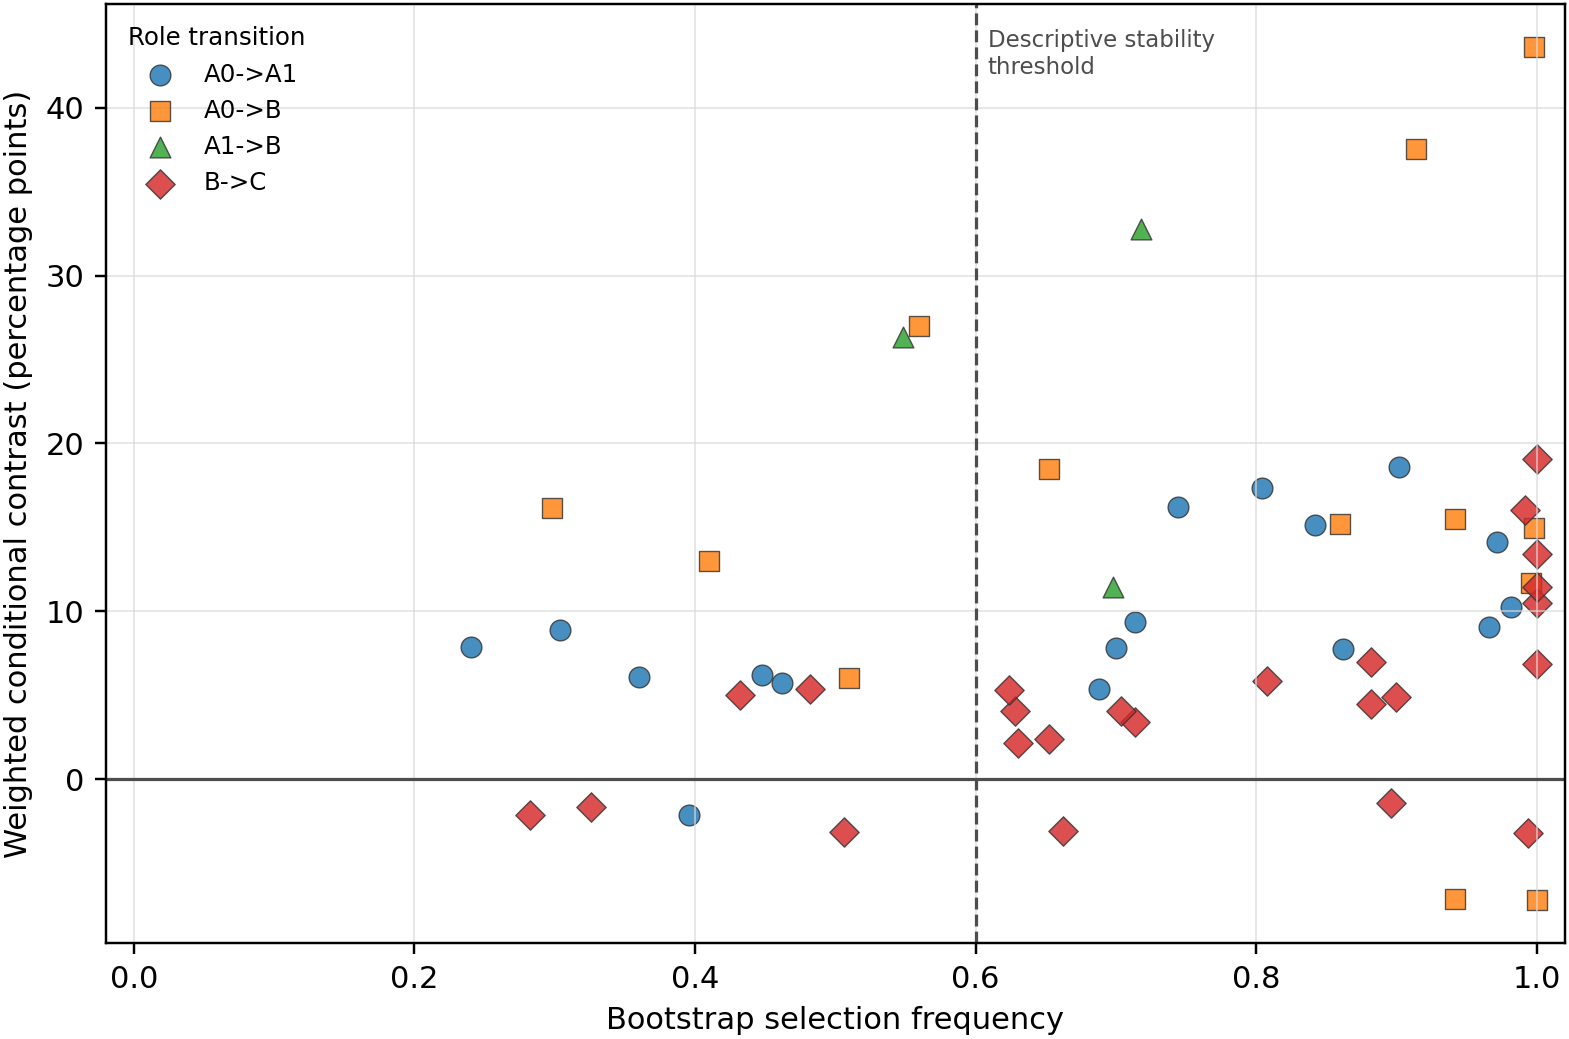

In [5]:
bootstrap = pd.read_csv(paths["network"] / "bn_bootstrap_edges.csv")
edges = pd.read_csv(paths["network"] / "bn_edges_full.csv")
contrasts = pd.read_csv(paths["network"] / "bn_conditional_contrasts.csv")
stable_threshold = config["bayesian_networks"]["bn_display_bootstrap_threshold"]
stable = edges.loc[edges["bootstrap_frequency"] >= stable_threshold].copy()
print(f"{len(edges)} full-sample edges; {len(stable)} with f >= {stable_threshold:.2f}")
print("Stable edges by transition:")
display(stable["transition"].value_counts().rename_axis("transition").reset_index(name="n_edges"))
main_columns = [
    "parent_label", "child_label", "transition", "bootstrap_frequency",
    "conditional_contrast_weighted", "conditional_contrast_min",
    "conditional_contrast_max", "conditional_contrast_pattern",
]
display(stable[[column for column in main_columns if column in stable.columns]].sort_values("bootstrap_frequency", ascending=False))
display(contrasts.head(30))
for name in ("global_bn_stable_dependencies.png", "bn_stability_vs_conditional_contrast.png"):
    path = paths["figures"] / name
    if path.is_file():
        display(Image(filename=str(path)))


## 4. Empirical recurrent scenarios


In [6]:
candidates = pd.read_csv(paths["scenarios"] / "scenario_candidates_all.csv")
recurrent = pd.read_csv(paths["scenarios"] / "recurrent_scenarios_all.csv")
thresholds = pd.read_csv(paths["scenarios"] / "scenario_threshold_summary.csv")
print("Admissible configurations:", len(candidates))
print("Closed recurrent scenarios:", len(recurrent))
display(thresholds)
display(recurrent[["scenario_id", "upstream_labels", "B_label", "C_label", "scenario_accident_count", "scenario_support", "confidence", "lift"]].head(20))


Admissible configurations: 660660
Closed recurrent scenarios: 20


,threshold,n_candidates,n_closed_patterns,percentage_of_observed_candidates_retained
0,3,120,107,0.025173
1,5,20,20,0.004196
2,8,1,1,0.000210
3,10,0,0,0.000000


,scenario_id,upstream_labels,B_label,C_label,scenario_accident_count,scenario_support,confidence,lift
0,SC_11331,A0_026,B_004,C_020,8,0.002491,0.347826,14.896232
1,SC_01740,A0_004,B_000,C_023,7,0.002179,0.166667,16.729167
2,SC_01739,A0_004,B_000,C_022,7,0.002179,0.166667,15.295238
3,SC_07562,A0_017,B_006,C_034,7,0.002179,0.122807,10.380425
4,SC_17175,A1_001,B_000,C_014,7,0.002179,0.166667,9.229885
5,SC_04106,A0_009,B_006,C_010,7,0.002179,0.112903,4.649297
6,SC_11327,A0_026,B_004,C_016,6,0.001868,0.260870,17.100266
7,SC_09186,A0_021,B_004,C_020,6,0.001868,0.352941,15.115294
8,SC_17184,A1_001,B_000,C_023,6,0.001868,0.142857,14.339286
9,SC_14716,A0_034,B_003,C_012,6,0.001868,0.260870,14.201916


## 5. Recurrence relative to the Bayesian-network background


Scenarios with D_BN > 0: 20
Scenarios with D_BN < 0: 0
Median |D_BN| (pp): 0.123457541426515
Maximum |D_BN| (pp): 0.22990904074711


,scenario_id,BN_implied_support,BN_expected_accident_count,BN_support_discrepancy,BN_support_discrepancy_pp,BN_support_interestingness,BN_CPT_estimation,BN_MLE_support,BN_Jeffreys_support,BN_MLE_minus_Jeffreys_pp,internal_BN_edges,n_internal_BN_edges
0,SC_11331,0.000192,0.615322,0.002299,0.229909,0.002299,Jeffreys,NaN,0.000192,NaN,B__T05->C__T21,1
9,SC_14716,0.000098,0.313618,0.001770,0.177036,0.001770,Jeffreys,NaN,0.000098,NaN,NaN,0
5,SC_04106,0.000445,1.428649,0.001735,0.173454,0.001735,Jeffreys,NaN,0.000445,NaN,A0__T10->B__T07,1
7,SC_09186,0.000137,0.439049,0.001731,0.173130,0.001731,Jeffreys,NaN,0.000137,NaN,B__T05->C__T21,1
6,SC_11327,0.000210,0.673924,0.001658,0.165818,0.001658,Jeffreys,NaN,0.000210,NaN,B__T05->C__T17,1
3,SC_07562,0.000549,1.762386,0.001631,0.163064,0.001631,Jeffreys,NaN,0.000549,NaN,B__T07->C__T35,1
11,SC_421884,0.000008,0.025758,0.001549,0.154864,0.001549,Jeffreys,NaN,0.000008,NaN,B__T05->C__T21,1
13,SC_11321,0.000062,0.200447,0.001494,0.149426,0.001494,Jeffreys,NaN,0.000062,NaN,NaN,0
18,SC_08396,0.000082,0.263325,0.001475,0.147468,0.001475,Jeffreys,NaN,0.000082,NaN,NaN,0
19,SC_07109,0.000158,0.508727,0.001398,0.139828,0.001398,Jeffreys,NaN,0.000158,NaN,NaN,0


,scenario_id,BN_CPT_estimation,BN_MLE_support,BN_Jeffreys_support,BN_MLE_minus_Jeffreys_pp
0,SC_11331,Jeffreys,NaN,0.000192,NaN
1,SC_01740,Jeffreys,NaN,0.001431,NaN
2,SC_01739,Jeffreys,NaN,0.001564,NaN
3,SC_07562,Jeffreys,NaN,0.000549,NaN
4,SC_17175,Jeffreys,NaN,0.001934,NaN
5,SC_04106,Jeffreys,NaN,0.000445,NaN
6,SC_11327,Jeffreys,NaN,0.000210,NaN
7,SC_09186,Jeffreys,NaN,0.000137,NaN
8,SC_17184,Jeffreys,NaN,0.001459,NaN
9,SC_14716,Jeffreys,NaN,0.000098,NaN


,Scenario,n_s,Support,Confidence,Lift,p_BN,mu_BN,D_BN_pp
0,S1: A0_026 → B_004 → C_020,8,0.25%,34.8%,14.9x,0.02%,0.615322,0.229909
1,S2: A0_004 → B_000 → C_023,7,0.22%,16.7%,16.7x,0.14%,4.597255,0.074805
2,S3: A0_004 → B_000 → C_022,7,0.22%,16.7%,15.3x,0.16%,5.024906,0.061491
3,S4: A0_017 → B_006 → C_034,7,0.22%,12.3%,10.4x,0.05%,1.762386,0.163064
4,S5: A1_001 → B_000 → C_014,7,0.22%,16.7%,9.2x,0.19%,6.210414,0.024582
5,S6: A0_009 → B_006 → C_010,7,0.22%,11.3%,4.6x,0.04%,1.428649,0.173454


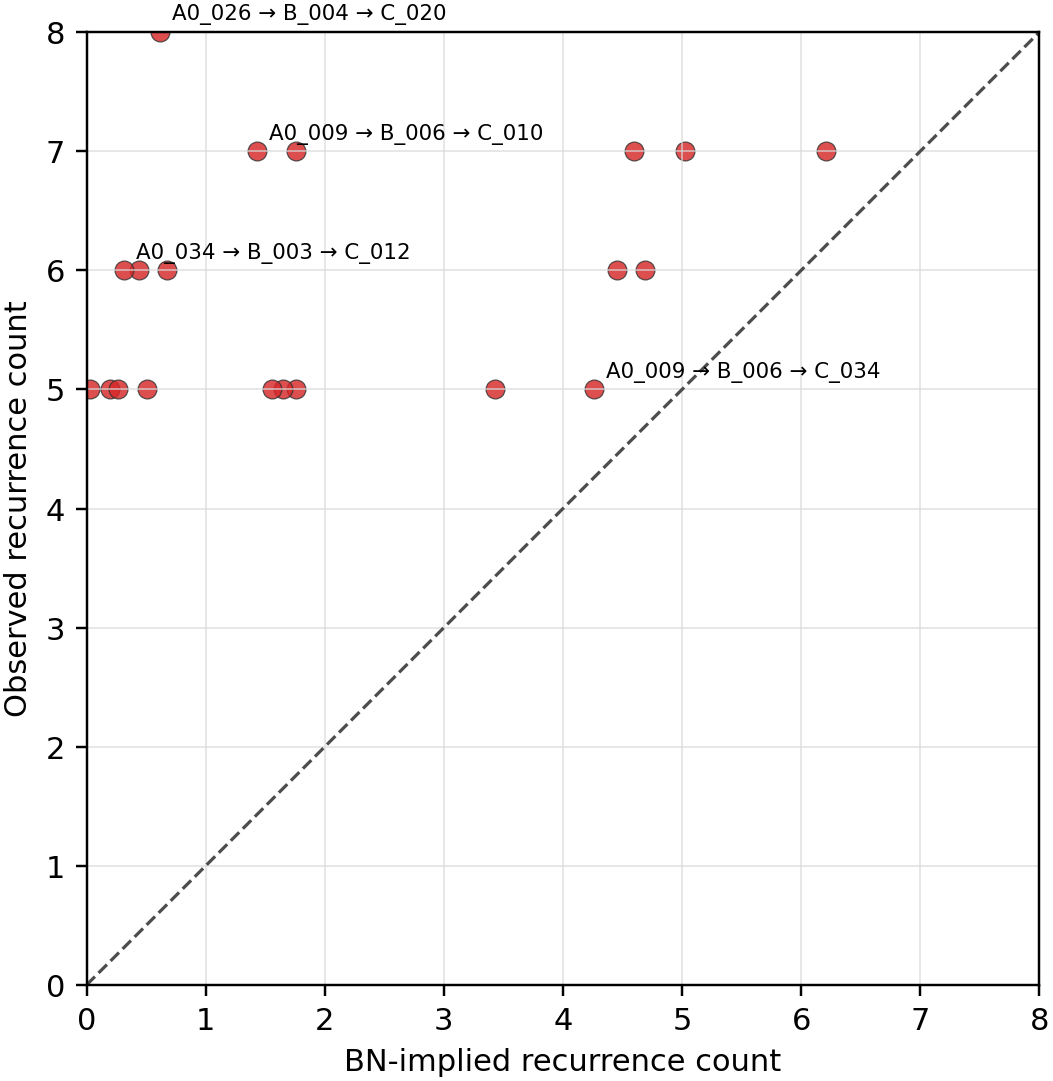

In [7]:
discrepancy = pd.read_csv(paths["scenarios"] / "scenario_bn_discrepancy.csv")
sensitivity = pd.read_csv(paths["scenarios"] / "scenario_bn_cpt_sensitivity.csv")
article = pd.read_csv(paths["scenarios"] / "scenarios_article_table.csv")
signed = discrepancy["BN_support_discrepancy"].dropna()
print("Scenarios with D_BN > 0:", int((signed > 0).sum()))
print("Scenarios with D_BN < 0:", int((signed < 0).sum()))
print("Median |D_BN| (pp):", 100.0 * float(signed.abs().median()))
print("Maximum |D_BN| (pp):", 100.0 * float(signed.abs().max()))
display(discrepancy.sort_values("BN_support_interestingness", ascending=False).head(20))
display(sensitivity[["scenario_id", "BN_CPT_estimation", "BN_MLE_support", "BN_Jeffreys_support", "BN_MLE_minus_Jeffreys_pp"]].head(20))
display(article)
path = paths["figures"] / "observed_vs_bn_implied_recurrence.png"
if path.is_file():
    display(Image(filename=str(path)))


## 6. Files for the manuscript


In [8]:
for folder in (paths["network"], paths["scenarios"], paths["figures"]):
    print(folder)
    for path in sorted(folder.glob("*")):
        if path.is_file():
            print("  ", path.name)


C:\Users\aho\Documents\analysis factor project\SAFER\text\recurrent_scenarios\runs\theme_discovery_audit\metallurgie\bn_results_exact\network
   bn_bootstrap_edges.csv
   bn_conditional_contrasts.csv
   bn_cpt_support_diagnostics.csv
   bn_edges_full.csv
   bn_final_cpts.csv
   bn_jeffreys_cpts.csv
   bn_local_scores.csv
   bn_mle_cpts.csv
   bn_selected_parent_sets.csv
   bn_stable_edges_main.csv
   global_bn_bootstrap_edges.csv
   global_bn_edge_contrast_strata.csv
   global_bn_edges.csv
   global_bn_summary.csv
   stable_negative_edges.csv
C:\Users\aho\Documents\analysis factor project\SAFER\text\recurrent_scenarios\runs\theme_discovery_audit\metallurgie\bn_results_exact\scenarios
   recurrent_scenarios_all.csv
   scenario_bn_cpt_sensitivity.csv
   scenario_bn_discrepancy.csv
   scenario_candidates_all.csv
   scenario_prevention_summary.csv
   scenario_threshold_summary.csv
   scenarios_article.csv
   scenarios_article_extended.csv
   scenarios_article_table.csv
   scenarios_latex.c